In [124]:
import pandas as pd 

train=pd.read_csv(r"C:\Users\om420\Downloads\Human Activity Recognition with Smartphones dataset\train.csv")

test=pd.read_csv(r"C:\Users\om420\Downloads\Human Activity Recognition with Smartphones dataset\test.csv")

train.head()


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

y_train = encoder.fit_transform(train[['Activity']])

y_test = encoder.transform(test[['Activity']])

In [126]:
X_train = train.drop(['Activity', 'subject'], axis=1).values
X_test = test.drop(['Activity', 'subject'], axis=1).values

In [127]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [128]:
import tensorflow as tf             
from tensorflow import keras 
from keras.layers import Dense,Conv1D,Flatten,MaxPooling1D,Dropout
from tensorflow.keras.models import Sequential

In [ ]:
model=Sequential()

model.add(Conv1D(kernel_size=3,filters=32,activation='relu',padding='valid',input_shape=(561,1)))
model.add(MaxPooling1D(pool_size=3))
model.add(Dropout(0.5))

model.add(Conv1D(kernel_size=3,filters=64,activation='relu',padding='valid'))
model.add(MaxPooling1D(pool_size=3))
model.add(Dropout(0.5))

model.add(Conv1D(kernel_size=3,filters=64,activation='relu',padding='valid'))
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())


model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(6,activation='softmax'))


In [134]:
model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='adam')

In [135]:
model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_37 (Conv1D)              │ (None, 559, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_35 (MaxPooling1D) │ (None, 186, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 186, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_38 (Conv1D)              │ (None, 184, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_36 (MaxPooling1D) │ (None, 61, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 61, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_39 (Conv1D)              │ (None, 59, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_37 (MaxPooling1D) │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │       237,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,030 (1.01 MB)

 Trainable params: 265,030 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [141]:
X_train.shape

(7352, 561, 1)

In [ ]:
history = model.fit(
    X_train,     
    y_train,    
    epochs=100, 
    batch_size=50, 
    validation_split=0.2
)

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4106 - loss: 1.2057 - val_accuracy: 0.6540 - val_loss: 0.9470
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6461 - loss: 0.7972 - val_accuracy: 0.8219 - val_loss: 0.6208
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7548 - loss: 0.5525 - val_accuracy: 0.8151 - val_loss: 0.5163
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7968 - loss: 0.4512 - val_accuracy: 0.8579 - val_loss: 0.3915
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8230 - loss: 0.3937 - val_accuracy: 0.8844 - val_loss: 0.3339
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8420 - loss: 0.3607 - val_accuracy: 0.8804 - val_loss: 0.3338
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8504 - loss: 0.3433 - val_accuracy: 0.8953 - val_loss: 0.3062
Epoch 8/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8602 - loss: 0.3198 - 

In [137]:

loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9091 - loss: 0.2604
Test Accuracy: 0.9090600609779358


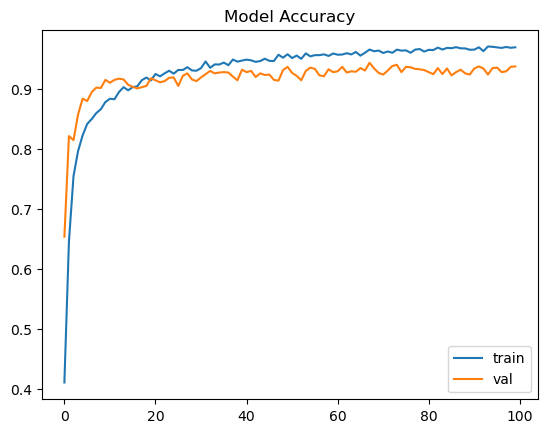

In [138]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Model Accuracy")
plt.show()

In [140]:
train.shape

(7352, 563)